In [1]:
%run header.ipynb
%config InlineBackend.figure_formats = ['svg']



from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

-----

# Spectral Leakage

Both animated examples above work with an ideal assumption: the input signal has an integer frequency and falls directly into a DFT bin.
As a consequence, there is always an integer amount of cycles of the input signal in the analysis frame.
This is usually not the case when analysing audio signals (or any physical signal).

The following animation shows the same sine example as above, but with a frequency of 10.66.
The DFT shows *smeared* peaks for both the real and imaginary part with different signs,
with a center located between two DFT bins.




In [2]:
fig = plt.figure()

N = 100

n = np.linspace(0, 1, N)
K = np.linspace(0, N, N)

x = np.sin(2*np.pi*10.66*n)

ax1 = plt.subplot(3,1,1)
ax1.plot(n,x,'k')
ax1.set_xlabel('$n/N$')
ax1.set_ylabel('$x[n]$')
ax1.set_ylim([-1.1,1.1])

ax2 = plt.subplot(3,1,2)
sin,  = ax2.plot(n, np.sin(n), color='green', linewidth=1)
cos,  = ax2.plot(n, np.cos(n), color='red',linewidth=1)
ax2.legend(['Real (cosine)','Imag (sine)'], loc='lower right')#, bbox_to_anchor=(0, 0.5))
ax2.set_xlabel('$n/N$')
ax2.set_ylabel('$e^{-j 2 \pi k n/N}$')
ax2.set_ylim([-1.1,1.1])

ax3 = plt.subplot(3,1,3)
XR = np.zeros([N])
XI = np.zeros([N])
XRpl, = ax3.plot(K,XR,'green')
XIpl, = ax3.plot(K,XI,'red')
ax3.legend(['$\mathcal{Re}(X) $','$\mathcal{Im}(X)$'], loc='upper right')#, bbox_to_anchor=(0, 0.5))
ax3.set_ylim([-50,50])
ax3.set_xlabel('$k$')
ax3.set_ylabel('DFT')


def animate(k):

    real = np.cos(2 * np.pi * k * n)
    imag = np.sin(2 * np.pi * k * n)
    
    sin.set_data(n, real)
    cos.set_data(n, imag)

    XR[k] = sum(x*real)
    XI[k] = sum(x*imag)
    
    XRpl.set_data(K[0:k], XR[0:k])
    XIpl.set_data(K[0:k], XI[0:k])
    

plt.tight_layout();
a = matplotlib.animation.FuncAnimation(fig, animate, frames=N);
plt.close()
from IPython.display import HTML
HTML(a.to_jshtml())


-----

## Magnitude Spectrum

Plotting the magnitude spectrum of the odd-frequency signal gives the pattern most commonly seen when visualizing a sine or cosine -
two smeared peaks at the positive and negative fundamental frequency.


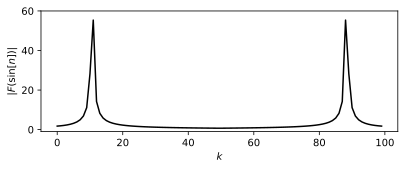

In [3]:
fig = plt.figure()

ax1 = plt.subplot(2,1,1)
plt.plot(abs(XR)+abs(XI),'k')
ax1.set_ylim([-1,60])
ax1.set_xlabel('$k$')
ax1.set_ylabel('$|F(\sin[n])|$');

